# Asian Monsoon Flood Prediction — Finding the Hidden Leak

This synthetic benchmark simulates flood risk across South & Southeast Asian river basins. It also hides a **data-leakage trap** that will fool a careless model into scoring near-perfect and teach us nothing.

**Our plan:** expose the leak, remove it, then build an *honest* flood classifier from the real physical drivers.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
WATER, DEEP, SAND = "#2a9d8f", "#264653", "#e9c46a"

path = "/kaggle/input/datasets/aliahmadmphil/asian-monsoon-flood-prediction-and-risk-index/asian_monsoon_flood_index/Asian_Monsoon_Flood_Risk_Index.csv"
df = pd.read_csv(path)
print("shape:", df.shape)
df.head()

shape: (15000, 9)


,Region_ID,Monsoon_Intensity_Index,Topographic_Wetness_Index,River_Discharge_Rate_CMS,Deforestation_Rate_Pct,Urban_Impervious_Pct,Soil_Moisture_Anomaly,Flood_Probability,Flood_Target_Binary
0,Chao_Phraya_TH,74.362844,16.449025,1564.361885,27.566675,16.678039,0.658005,0.603003,0
1,Red_River_VN,57.222951,10.753842,205.219016,35.166157,34.865899,0.358294,0.411600,0
2,Mekong_Delta_VN,45.945754,16.092284,1109.951968,11.538884,35.505539,0.734650,0.541335,0
3,Red_River_VN,62.301348,11.934957,279.376150,14.406374,53.279847,0.873312,0.581188,0
4,Red_River_VN,83.526681,14.355790,4054.892388,76.178339,17.206297,0.428771,0.538685,0


## The Setup

15,000 river-basin records, 6 physical features, and **two** outcome columns: a continuous `Flood_Probability` and a `Flood_Target_Binary`. Only 7.3% are floods so this is an **imbalanced classification** problem and accuracy will lie to us.

Flood rate: 0.073
Flood_Target_Binary
0    13911
1     1089
Name: count, dtype: int64


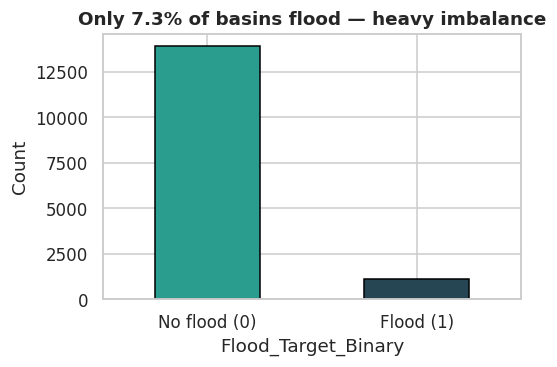

In [2]:
print("Flood rate:", df["Flood_Target_Binary"].mean().round(3))
print(df["Flood_Target_Binary"].value_counts())

ax = df["Flood_Target_Binary"].value_counts().plot(
    kind="bar", color=[WATER, DEEP], edgecolor="black", figsize=(5,3.5))

ax.set_xticklabels(["No flood (0)", "Flood (1)"], rotation=0)
ax.set_title("Only 7.3% of basins flood — heavy imbalance")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

## Leakage Trap

`Flood_Probability` looks like a useful feature. It isn't, the binary target *is* just this column thresholded. Let's prove it then watch it wreck a model.

In [3]:
p = df["Flood_Probability"]

print("Max prob among NON-floods:", round(p[df.Flood_Target_Binary == 0].max(), 4))
print("Min prob among FLOODS:    ", round(p[df.Flood_Target_Binary == 1].min(), 4))
print("\nTarget is essentially  Flood_Probability >= 0.62")

Max prob among NON-floods: 0.6199
Min prob among FLOODS:     0.62

Target is essentially  Flood_Probability >= 0.62


### Watch it fool a model

Train an identical model twice once *with* `Flood_Probability` and once *without*. The gap between them is the size of the trap.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

y = df["Flood_Target_Binary"]
leaky_feats = ['Monsoon_Intensity_Index','Topographic_Wetness_Index','River_Discharge_Rate_CMS',
               'Deforestation_Rate_Pct','Urban_Impervious_Pct','Soil_Moisture_Anomaly','Flood_Probability']
clean_feats = leaky_feats[:-1]

def quick_eval(feats, label):
    Xtr, Xte, ytr, yte = train_test_split(df[feats], y, test_size=0.2,
                                          random_state=42, stratify=y)
    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]
    pred = m.predict(Xte)
    
    print(f"{label:28s} F1={f1_score(yte, pred):.3f}  AUC={roc_auc_score(yte, proba):.3f}")

quick_eval(leaky_feats, "WITH Flood_Probability")
quick_eval(clean_feats, "WITHOUT (honest)")

WITH Flood_Probability       F1=1.000  AUC=1.000
WITHOUT (honest)             F1=0.458  AUC=0.947


### The verdict

With `Flood_Probability` the model scores a perfect and meaningless 1.000: it merely memorized the 0.62 threshold. The honest model earns **AUC ≈ 0.95** (it ranks risk well) but a low **F1 ≈ 0.46** at the default cutoff a sign we'll need to tune the decision threshold, not the model. From here, `Flood_Probability` is dropped.

## What Drives a Flood? (TheHonest Features Only)

Six physical features remain. Let's see which actually separate floods from non-floods and confirm the one our diagnostics flagged as noise.

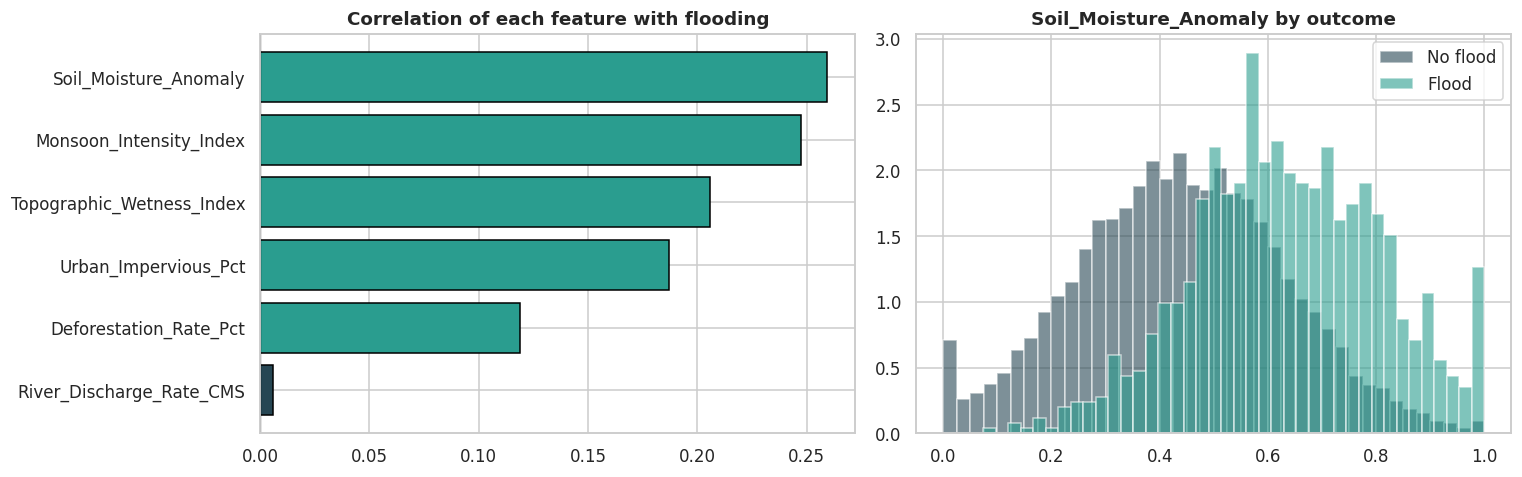

Weakest signal: River_Discharge_Rate_CMS  correlation ≈ 0.006


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

corrs = df[clean_feats + ["Flood_Target_Binary"]].corr()["Flood_Target_Binary"] \
          .drop("Flood_Target_Binary").sort_values()

axes[0].barh(corrs.index, corrs.values,
             color=[DEEP if v < 0.05 else WATER for v in corrs.values], edgecolor="black")

axes[0].set_title("Correlation of each feature with flooding")
axes[0].axvline(0, color="black", lw=0.8)

top = corrs.index[-1]

for lab, color in [(0, DEEP), (1, WATER)]:
    axes[1].hist(df[df.Flood_Target_Binary == lab][top], bins=40, alpha=0.6,
                 color=color, label=f"{'Flood' if lab else 'No flood'}", density=True)
    
axes[1].set_title(f"{top} by outcome")
axes[1].legend()

plt.tight_layout(); plt.show()
print("Weakest signal:", corrs.abs().idxmin(), " correlation ≈", round(corrs[corrs.abs().idxmin()], 3))

## Preprocessing and Model Lineup

We one-hot encode `Region_ID`, scale for the linear model only and compare four classifiers via stratified cross-validation, always against a baseline, always on F1 (accuracy is meaningless at 7% prevalence).

In [6]:
from sklearn.preprocessing import StandardScaler

X = pd.get_dummies(df[clean_feats + ["Region_ID"]], columns=["Region_ID"], drop_first=True)
y = df["Flood_Target_Binary"]
print("Feature matrix:", X.shape, "| one-hot added", X.shape[1] - len(clean_feats), "region columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train {X_train.shape[0]} | Test {X_test.shape[0]} | flood rate {y_train.mean():.3f}/{y_test.mean():.3f}")

Feature matrix: (15000, 11) | one-hot added 5 region columns
Train 12000 | Test 3000 | flood rate 0.073/0.073


### Cross-validated comparison

Four models, 5-fold stratified CV, scored on F1. The baseline is our zero line anything that can't beat "never predict flood" is useless.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Baseline (never flood)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":    LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest":          RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "XGBoost":                XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                                            subsample=0.8, colsample_bytree=0.8,
                                            eval_metric="logloss", scale_pos_weight=spw, random_state=42),
}

needs_scaling = {"Logistic Regression"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    Xt = X_train_s if name in needs_scaling else X_train.values
    s = cross_val_score(model, Xt, y_train, cv=cv, scoring="f1")
    cv_results[name] = s
    
    print(f"{name:24s} F1 = {s.mean():.3f} ± {s.std():.3f}")

Baseline (never flood)   F1 = 0.000 ± 0.000
Logistic Regression      F1 = 0.522 ± 0.009
Random Forest            F1 = 0.381 ± 0.025
XGBoost                  F1 = 0.551 ± 0.025


## Evaluation: A Tale of Two Metrics

XGBoost leads CV. Let's judge it honestly on the test set and confront the gap between its excellent *ranking* (AUC) and its mediocre *decisions* (F1).

Test AUC: 0.954
Test F1 : 0.561

              precision    recall  f1-score   support

    No flood       0.99      0.91      0.95      2782
       Flood       0.42      0.83      0.56       218

    accuracy                           0.91      3000
   macro avg       0.70      0.87      0.75      3000
weighted avg       0.94      0.91      0.92      3000



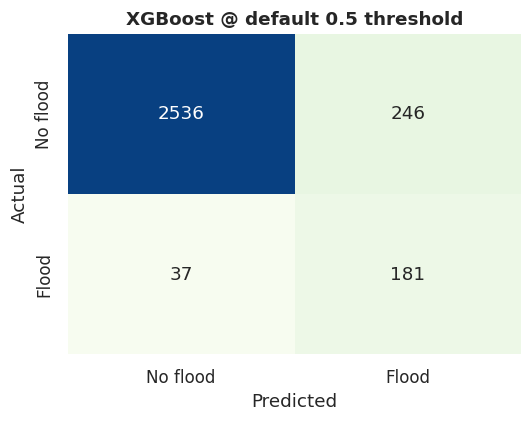

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

best = models["XGBoost"]
best.fit(X_train.values, y_train)
proba = best.predict_proba(X_test.values)[:, 1]
pred = best.predict(X_test.values)

print(f"Test AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"Test F1 : {f1_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["No flood", "Flood"]))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", cbar=False,
            xticklabels=["No flood", "Flood"], yticklabels=["No flood", "Flood"], ax=ax)

ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("XGBoost @ default 0.5 threshold")
plt.tight_layout(); plt.show()

## Fixing the Threshold

At 0.5 the model over-flags floods (recall 0.83, precision 0.42). The model isn't broken the cutoff is. Let's find the F1-optimal threshold, while remembering that in flood warning, **missing a flood costs more than a false alarm.**

Default 0.50 -> F1 0.561
Best    0.69 -> F1 0.609  (precision 0.52, recall 0.74)


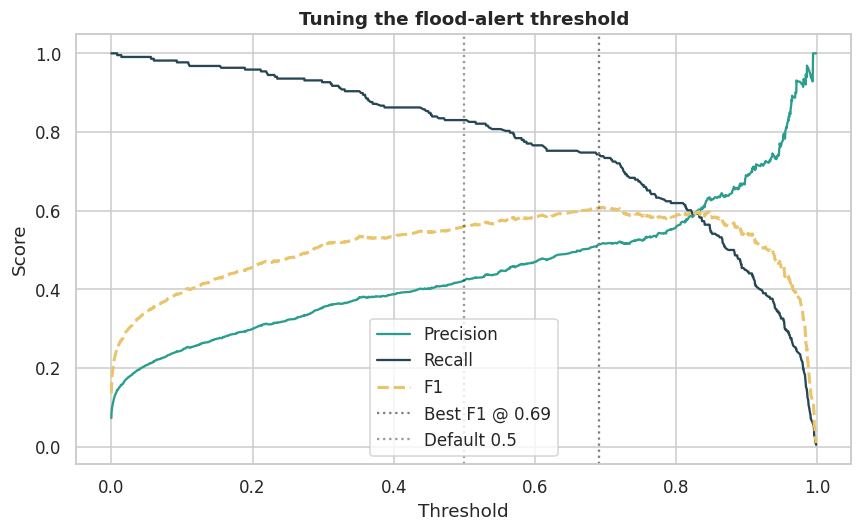

In [9]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_i = np.argmax(f1s)
best_t = thr[best_i]

print(f"Default 0.50 -> F1 {f1_score(y_test, proba >= 0.5):.3f}")
print(f"Best    {best_t:.2f} -> F1 {f1_score(y_test, proba >= best_t):.3f}  "
      f"(precision {prec[best_i]:.2f}, recall {rec[best_i]:.2f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thr, prec[:-1], color=WATER, label="Precision")
ax.plot(thr, rec[:-1], color=DEEP, label="Recall")
ax.plot(thr, f1s, color=SAND, ls="--", lw=2, label="F1")
ax.axvline(best_t, color="gray", ls=":", label=f"Best F1 @ {best_t:.2f}")
ax.axvline(0.5, color="black", ls=":", alpha=0.4, label="Default 0.5")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Tuning the flood-alert threshold")
plt.tight_layout(); plt.show()

### The trade-off is a choice, not just a number

Tuning to **0.69** lifts F1 to **0.61** (precision 0.42→0.52) by cutting false alarms mathematically better. But it now misses **26% of real floods**. In flood warning, a false alarm is an inconvenience; a missed flood is a catastrophe. A real agency would likely keep the *lower* threshold and tolerate false alarms.

**The lesson:** the "best" threshold depends on the cost of each error, not on F1 alone.

## What the Model Learned

Feature importance should echo our EDA: soil moisture and monsoon intensity on top, river discharge at the bottom. If it does, the model found real structure, not noise.

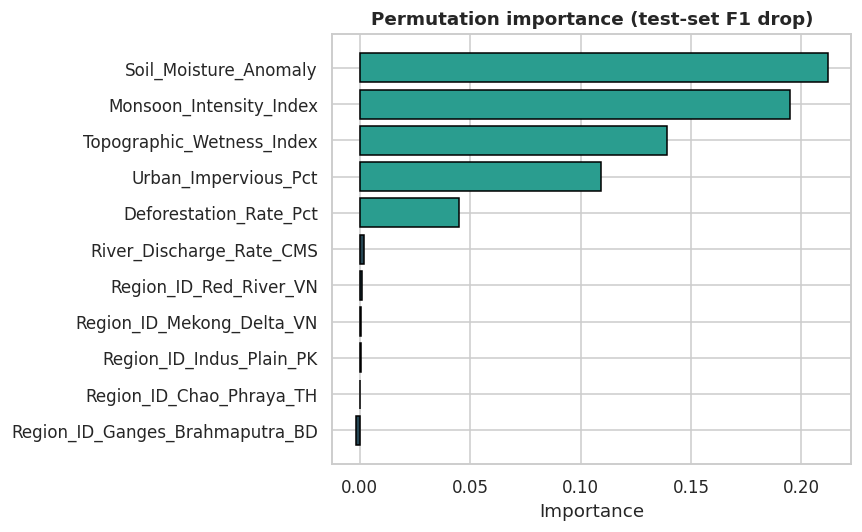

Least important: Region_ID_Ganges_Brahmaputra_BD → -0.0017


In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_test.values, y_test,
                              n_repeats=20, random_state=42, scoring="f1")

imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(imp.index, imp.values,
        color=[DEEP if v < 0.01 else WATER for v in imp.values], edgecolor="black")

ax.set_title("Permutation importance (test-set F1 drop)")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

print("Least important:", imp.index[0], "→", round(imp.iloc[0], 4))

## SHAP: How Each Feature Moves a Prediction

Importance tells us *which* features matter. SHAP shows *which direction* they push and lets us explain any single basin's risk score.

In [11]:
import shap

X_test_df = X_test.astype(float)

explainer = shap.TreeExplainer(best)
shap_values = explainer.shap_values(X_test_df)

print("SHAP values shape:", np.array(shap_values).shape, "(rows × features)")

SHAP values shape: (3000, 11) (rows × features)


### The global picture

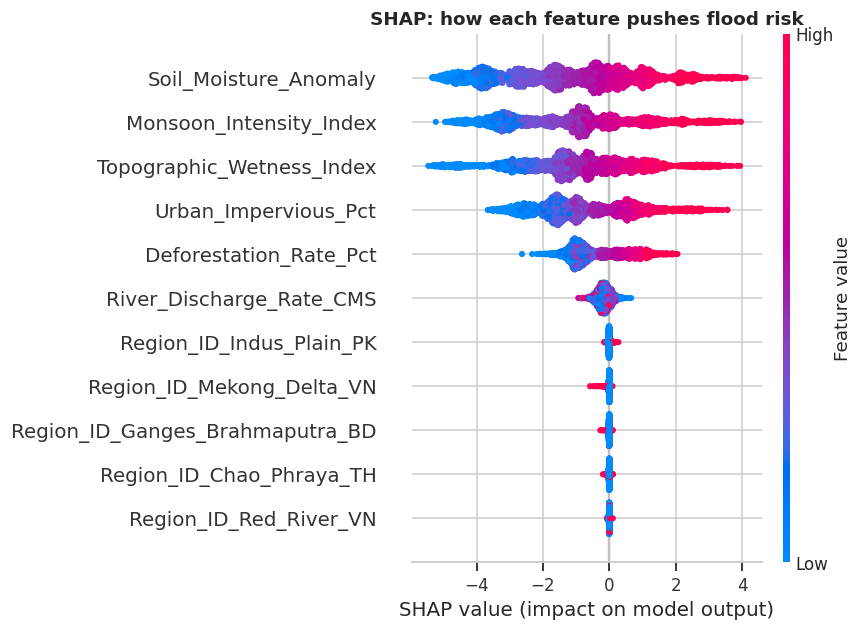

In [12]:
shap.summary_plot(shap_values, X_test_df, show=False)

plt.title("SHAP: how each feature pushes flood risk", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

### Explaining one high-risk basin

Basin #2606: model says P(flood) = 1.00 | actual: FLOOD


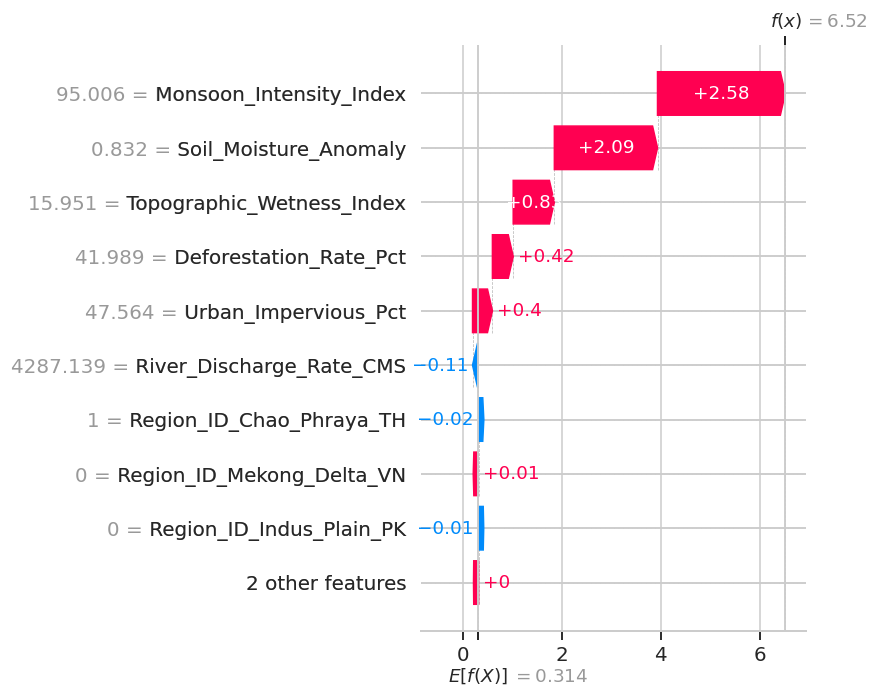

In [13]:
proba_all = best.predict_proba(X_test.values)[:, 1]
i = int(np.argmax(proba_all))

print(f"Basin #{i}: model says P(flood) = {proba_all[i]:.2f} | actual: "
      f"{'FLOOD' if y_test.iloc[i]==1 else 'no flood'}")

shap.plots.waterfall(
    shap.Explanation(values=shap_values[i],
                     base_values=explainer.expected_value,
                     data=X_test_df.iloc[i],
                     feature_names=list(X.columns)),
    show=False)

plt.tight_layout(); plt.show()

### Reading the SHAP plots

The physics is coherent. Soil moisture, monsoon intensity and topographic wetness dominate, **high values (red) consistently push toward flooding**, exactly as real hydrology predicts. Meanwhile river discharge and all region dummies sit flat at zero: three independent methods now agree they carry no signal.

The single-basin waterfall confirms it a real flood driven almost entirely by extreme monsoon intensity and high soil saturation, while a huge discharge value (4,287 m³/s) barely nudges the prediction. The model learned the drivers, not the labels.

## Does the Model Fail Unevenly Across Regions?

The region labels didn't help prediction but do some basins still get worse predictions than others? A model can be fair on average yet biased locally.

In [14]:
res = df.loc[X_test.index, ["Region_ID", "Flood_Target_Binary"]].copy()
res["pred"] = best.predict(X_test.values)

rows = []

for region, g in res.groupby("Region_ID"):
    floods = g[g.Flood_Target_Binary == 1]
    safe   = g[g.Flood_Target_Binary == 0]
    recall = (floods.pred == 1).mean() if len(floods) else np.nan         
    fa     = (safe.pred == 1).mean() if len(safe) else np.nan              
    rows.append({"Region": region, "n": len(g), "n_floods": len(floods),
                 "Recall": round(recall, 2), "False_alarm_rate": round(fa, 2)})

region_perf = pd.DataFrame(rows).sort_values("Recall", ascending=False)
print(region_perf.to_string(index=False))

               Region   n  n_floods  Recall  False_alarm_rate
        Ayeyarwady_MM 482        41    0.88              0.08
       Chao_Phraya_TH 512        35    0.86              0.08
      Mekong_Delta_VN 473        31    0.84              0.08
Ganges_Brahmaputra_BD 506        43    0.81              0.10
       Indus_Plain_PK 513        29    0.79              0.09
         Red_River_VN 514        39    0.79              0.10


### Geographically fair

Recall holds between **0.79 and 0.88** and false-alarm rates cluster tightly around **0.08–0.10** across all six basins, no region where the model collapses. Combined with the useless region dummies, this confirms the model relies on **transferable physics**, not memorized geography.

*Caveat:* with only ~30–43 floods per region, the modest recall spread is partly small-sample noise, so we read this as "roughly uniform," not a definitive ranking.

## The Threshold That Minimizes Real Harm

F1 treats a missed flood and a false alarm as equally bad. They aren't. If a missed flood costs **10×** a false alarm, what threshold actually minimizes total harm? We'll compute it and expect it to fall *below* the F1-optimal 0.69.

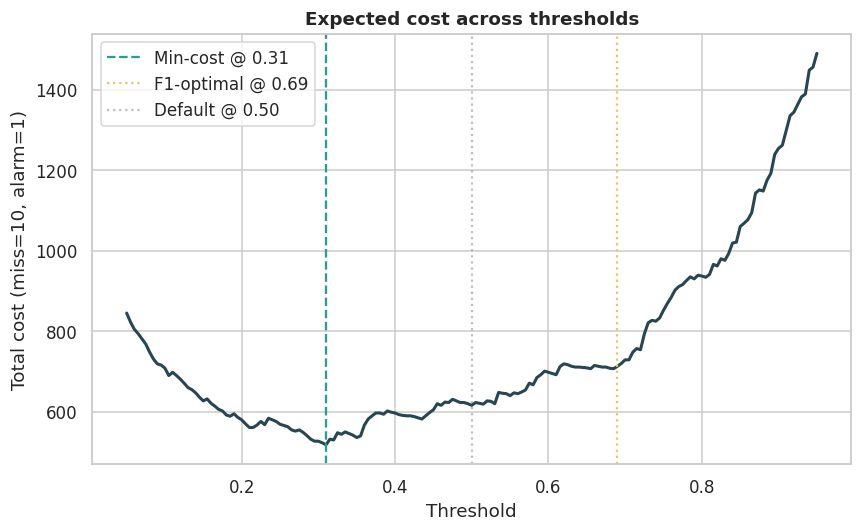

Cost-minimizing threshold: 0.31
  vs F1-optimal 0.69 and default 0.50


In [15]:
COST_MISS = 10
COST_FA   = 1

thresholds = np.linspace(0.05, 0.95, 181)
costs = []

for t in thresholds:
    pred_t = (proba >= t).astype(int)
    fn = ((y_test == 1) & (pred_t == 0)).sum()
    fp = ((y_test == 0) & (pred_t == 1)).sum()
    costs.append(fn * COST_MISS + fp * COST_FA)

costs = np.array(costs)
best_cost_t = thresholds[costs.argmin()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs, color=DEEP, lw=2)
ax.axvline(best_cost_t, color=WATER, ls="--", label=f"Min-cost @ {best_cost_t:.2f}")
ax.axvline(0.69, color=SAND, ls=":", label="F1-optimal @ 0.69")
ax.axvline(0.5, color="gray", ls=":", alpha=0.5, label="Default @ 0.50")
ax.set_xlabel("Threshold"); ax.set_ylabel(f"Total cost (miss={COST_MISS}, alarm={COST_FA})")
ax.set_title("Expected cost across thresholds")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Cost-minimizing threshold: {best_cost_t:.2f}")
print(f"  vs F1-optimal 0.69 and default 0.50")

### The metric decides the outcome

Two "optimal" thresholds, opposite directions: F1 says push *up* to **0.69**; a 10:1 cost ratio says push *down* to **0.31** to catch more floods. Chasing F1 here would nearly triple real-world cost. The data can't choose between them only the consequences of each error can. **Pick the metric that matches the stakes.**

## Conclusions

Turned a leaky synthetic benchmark into an honest, semi well-understood flood model.

**What we did**
- **Caught the leak:** `Flood_Probability` was just the target thresholded at 0.62. Leaving it in gave a fake 1.000 AUC; removing it gave an honest **0.95**.
- **Built an honest model:** XGBoost on six physical features i.e. soil moisture, monsoon intensity and topographic wetness driving predictions, confirmed by correlation, permutation importance and SHAP alike.
- **Diagnosed the metric gap:** high AUC (great ranking) but low F1 (poor default cutoff) the fix was the *threshold*, not the model.
- **Checked fairness:** performance held steady across all six river basins.
- **Quantified the trade-off:** the F1-optimal (0.69) and cost-optimal (0.31)
  thresholds point in opposite directions the choice depends on stakes, not data.

**Honest limitations**
- The data is **synthetic**; findings describe the generator, not real hydrology.
- River discharge and region labels carried no signal an artifact of how the data was built.
- Flood counts per region are small, so local metrics carry sampling noise.

**The takeaway:** the most valuable modeling skill here wasn't the algorithm, it was refusing the free 1.000, then asking what the numbers actually *mean*.

*Thanks for reading! If this helped you spot a leak you'd have missed an upvote is much appreciated lads!*